# KHÁM PHÁ VÀ THỐNG KÊ MÔ TẢ DỮ LIỆU SẢN LƯỢNG NĂNG LƯỢNG MẶT TRỜI (EDA)

Mục tiêu: Đọc dữ liệu từ Supabase, tính toán các chỉ số thống kê mô tả nâng cao cho TOÀN BỘ dữ liệu và dữ liệu LỌC, phân tích đa chiều (theo site, giờ, thời gian trong năm, loại pin).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import urllib.parse
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

load_dotenv()
db_user = os.getenv("DB_USER")
db_password = urllib.parse.quote_plus(os.getenv("DB_PASSWORD") or "")
db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")
print("Đã kết nối Database thành công!")


Đã kết nối Database thành công!


## 1. Tải và xử lý dữ liệu ban đầu

In [2]:
# Truy vấn dữ liệu thực tế (hourly measures)
query_measures = "SELECT * FROM bi_mart.mv_bi_mart_hourly_measures"
df_measures = pd.read_sql_query(query_measures, engine)

query_site = "SELECT site_id, campus_name, capacity_kw, panel FROM bi_mart.dim_solar_site"
df_site = pd.read_sql_query(query_site, engine)

df = df_measures.merge(df_site, on='site_id', how='left')

df['date'] = pd.to_datetime(df['date_id'].astype(str), format='%Y%m%d')
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

print(f"Kích thước TOÀN BỘ dữ liệu ban đầu: {df.shape}")
df.head()


Kích thước TOÀN BỘ dữ liệu ban đầu: (683385, 21)


,date_id,hourly_bucket,site_id,p_stc,e_hourly,pr_actual,pr_adjusted,loss_temp,e_expected,delta_baseline,...,cost_of_underperformance,co2_avoided_kg,equivalent_trees_planted,geo_id,campus_name,capacity_kw,panel,date,month,year
0,20220423,23,18,167.97,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18,Bundoora,167.97,Trina 330W,2022-04-23,4,2022
1,20220423,22,18,167.97,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18,Bundoora,167.97,Trina 330W,2022-04-23,4,2022
2,20220423,21,18,167.97,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18,Bundoora,167.97,Trina 330W,2022-04-23,4,2022
3,20220423,20,18,167.97,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18,Bundoora,167.97,Trina 330W,2022-04-23,4,2022
4,20220423,19,18,167.97,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,18,Bundoora,167.97,Trina 330W,2022-04-23,4,2022


## 2. Thống kê mô tả TOÀN BỘ dữ liệu (Chưa lọc null/0)

In [3]:
# Khai báo hàm thống kê mô tả đầy đủ
def advanced_describe(data):
    numeric_df = data.select_dtypes(include=[np.number]).drop(columns=['date_id', 'geo_id', 'year', 'month', 'hourly_bucket'], errors='ignore')
    
    stats = pd.DataFrame({
        'Count': numeric_df.count(),
        'Missing': numeric_df.isnull().sum(),
        'Mean': numeric_df.mean(),
        'Median': numeric_df.median(),
        'Mode': numeric_df.mode().iloc[0],
        'Std': numeric_df.std(),
        'Min': numeric_df.min(),
        '25%': numeric_df.quantile(0.25),
        '50%': numeric_df.quantile(0.50),
        '75%': numeric_df.quantile(0.75),
        'Max': numeric_df.max(),
        'Skewness': numeric_df.skew(),
        'Kurtosis': numeric_df.kurtosis()
    })
    return stats.round(2)

print("Thống kê mô tả cho TOÀN BỘ DỮ LIỆU (Chưa lọc capacity):")
advanced_describe(df)


Thống kê mô tả cho TOÀN BỘ DỮ LIỆU (Chưa lọc capacity):


,Count,Missing,Mean,Median,Mode,Std,Min,25%,50%,75%,Max,Skewness,Kurtosis
site_id,683385,0,21.69,22.00,27.0,12.31,1.00,11.00,22.00,33.00,42.00,-0.02,-1.21
p_stc,683385,0,55.82,34.32,0.0,105.44,0.00,0.00,34.32,58.90,539.80,3.49,12.19
e_hourly,683385,0,13.62,0.24,0.0,34.33,0.00,0.00,0.24,12.87,397.08,5.40,37.73
pr_actual,554901,128484,0.33,0.00,0.0,0.83,0.00,0.00,0.00,0.45,41.29,7.35,105.73
pr_adjusted,683385,0,0.37,0.00,0.0,0.41,0.00,0.00,0.00,0.83,0.85,0.21,-1.95
loss_temp,683385,0,0.01,0.00,0.0,0.03,0.00,0.00,0.00,0.01,0.19,2.38,4.93
e_expected,683277,108,7.91,0.00,0.0,28.36,0.00,0.00,0.00,2.85,441.77,7.46,69.55
delta_baseline,683277,108,5.71,0.00,0.0,24.05,-282.12,0.00,0.00,3.50,397.08,5.60,64.36
estimated_revenue,683385,0,26405.13,469.36,0.0,66522.83,0.00,0.00,469.36,24936.61,769539.07,5.40,37.73
cost_of_underperformance,683385,0,2742.63,0.00,0.0,15022.02,0.00,0.00,0.00,0.00,546749.02,12.00,196.41


## 3. Lọc dữ liệu và so sánh thống kê

In [4]:
# Lọc các site có capacity khác 0 và không null
df_filtered = df[(df['capacity_kw'].notnull()) & (df['capacity_kw'] != 0)]
print(f"Kích thước dữ liệu SAU KHI LỌC (capacity != 0): {df_filtered.shape}")
print(f"Số lượng site bị loại bỏ (capacity = 0 hoặc null): {df['site_id'].nunique() - df_filtered['site_id'].nunique()}")

print("\nThống kê mô tả dữ liệu SAU KHI LỌC:")
advanced_describe(df_filtered)


Kích thước dữ liệu SAU KHI LỌC (capacity != 0): (400210, 21)
Số lượng site bị loại bỏ (capacity = 0 hoặc null): 17

Thống kê mô tả dữ liệu SAU KHI LỌC:


,Count,Missing,Mean,Median,Mode,Std,Min,25%,50%,75%,Max,Skewness,Kurtosis
site_id,400210,0,27.05,26.00,27.0,8.01,14.00,20.00,26.00,34.00,40.00,0.01,-1.31
p_stc,400210,0,95.32,51.15,539.8,123.37,21.39,39.27,51.15,77.22,539.80,2.79,6.62
e_hourly,400210,0,14.46,0.25,0.0,36.70,0.00,0.00,0.25,13.69,395.91,5.10,32.24
pr_actual,400157,53,0.46,0.00,0.0,0.95,0.00,0.00,0.00,0.73,41.29,6.47,82.34
pr_adjusted,400210,0,0.37,0.00,0.0,0.41,0.00,0.00,0.00,0.84,0.85,0.22,-1.94
loss_temp,400210,0,0.01,0.00,0.0,0.03,0.00,0.00,0.00,0.00,0.18,2.58,6.12
e_expected,400157,53,13.51,0.00,0.0,36.03,0.00,0.00,0.00,13.88,441.77,5.76,40.86
delta_baseline,400157,53,0.95,0.00,0.0,16.41,-282.12,0.00,0.00,0.68,232.99,0.75,35.09
estimated_revenue,400210,0,28014.83,488.29,0.0,71127.36,0.00,0.00,488.29,26526.38,767281.67,5.10,32.24
cost_of_underperformance,400210,0,4683.22,0.00,0.0,19396.99,0.00,0.00,0.00,0.00,546749.02,9.22,115.74


## 4. Phân tích theo Site Key (site_id)

,count,mean,sum,std,max
site_id,,,,,
27,19961,66.95,1336370.84,98.91,395.91
25,15737,58.46,920054.96,88.04,339.90
19,15737,30.46,479295.30,45.60,176.24
18,15470,26.11,403964.40,38.79,149.28
15,16265,13.54,220166.66,20.05,77.42
33,16073,12.71,204357.98,19.82,76.75
24,16073,12.40,199308.53,18.68,72.14
20,16073,11.64,187137.30,17.52,68.25
31,16073,11.08,178067.27,17.19,65.87


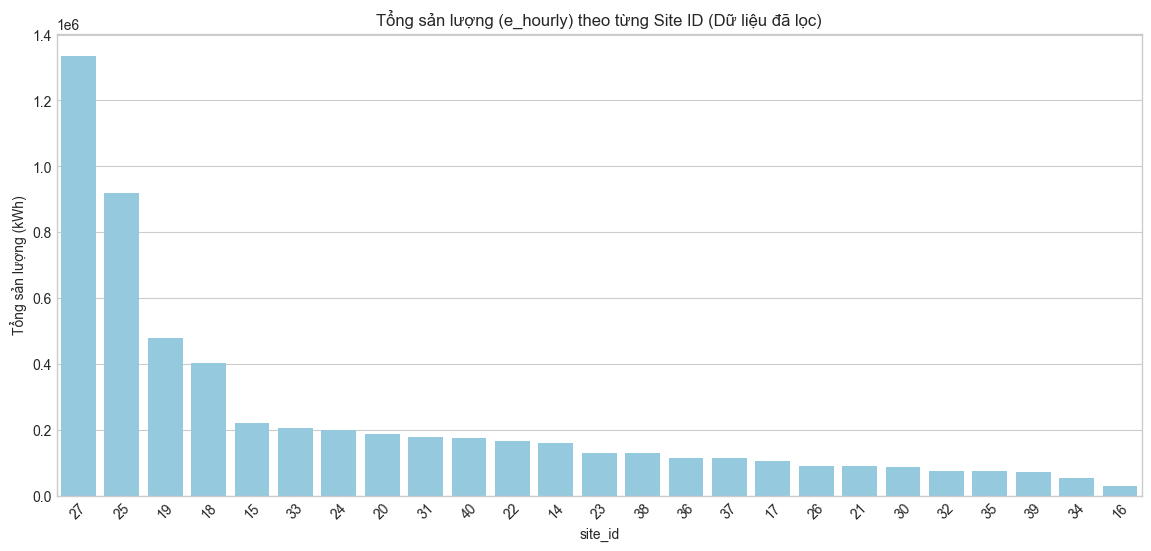

In [5]:
# Thống kê theo site_id (Site Key)
site_stats = df_filtered.groupby('site_id')['e_hourly'].agg(['count', 'mean', 'sum', 'std', 'max']).round(2).sort_values('sum', ascending=False)
display(site_stats.head(10))

plt.figure(figsize=(14,6))
sns.barplot(x=site_stats.index, y='sum', data=site_stats, color='skyblue', order=site_stats.index)
plt.title('Tổng sản lượng (e_hourly) theo từng Site ID (Dữ liệu đã lọc)')
plt.xticks(rotation=45)
plt.ylabel('Tổng sản lượng (kWh)')
plt.show()


## 5. Phân tích theo Giờ (Hour of day)

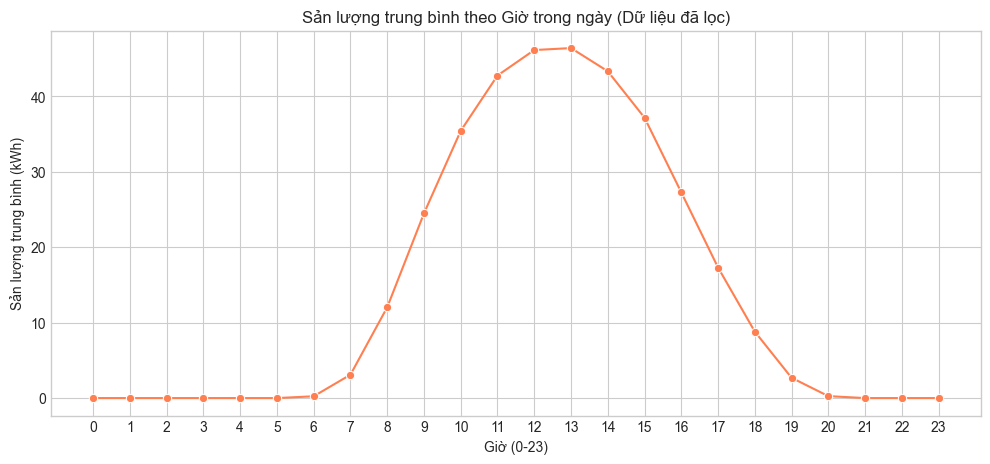

In [6]:
# Thống kê theo giờ
hour_stats = df_filtered.groupby('hourly_bucket')['e_hourly'].agg(['mean', 'sum']).round(2)

plt.figure(figsize=(12,5))
sns.lineplot(x=hour_stats.index, y='mean', data=hour_stats, marker='o', color='coral')
plt.title('Sản lượng trung bình theo Giờ trong ngày (Dữ liệu đã lọc)')
plt.xlabel('Giờ (0-23)')
plt.ylabel('Sản lượng trung bình (kWh)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


## 6. Phân tích theo Thời gian (Tháng)

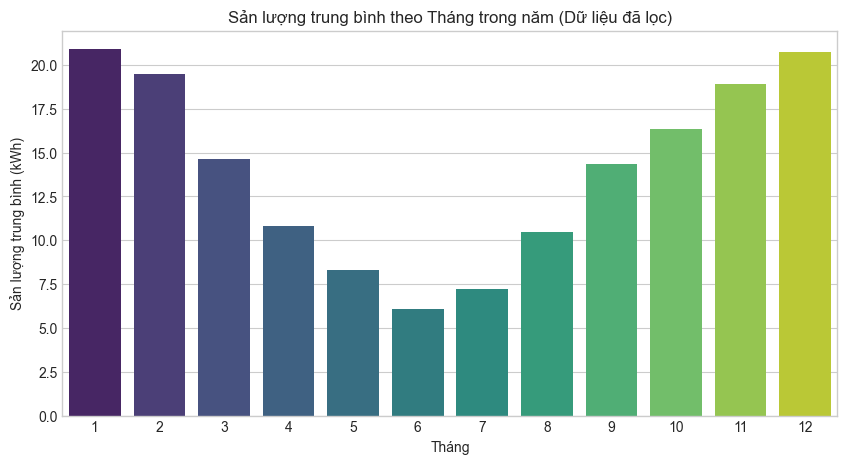

In [7]:
# Thống kê theo thời gian trong năm (tháng)
month_stats = df_filtered.groupby('month')['e_hourly'].agg(['mean', 'sum']).round(2)

plt.figure(figsize=(10,5))
sns.barplot(x=month_stats.index, y='mean', data=month_stats, palette='viridis')
plt.title('Sản lượng trung bình theo Tháng trong năm (Dữ liệu đã lọc)')
plt.xlabel('Tháng')
plt.ylabel('Sản lượng trung bình (kWh)')
plt.show()


## 7. Phân tích theo Loại Pin Năng Lượng (Panel)

,count,mean,sum,std
panel,,,,
SunpowerSPR-E20-435-COM,19961,66.95,1336370.84,98.91
Trina 330W,255821,14.38,3678507.90,32.18
Trina 310W,112640,6.59,742324.00,11.58
TBD,11788,2.38,28047.99,3.63


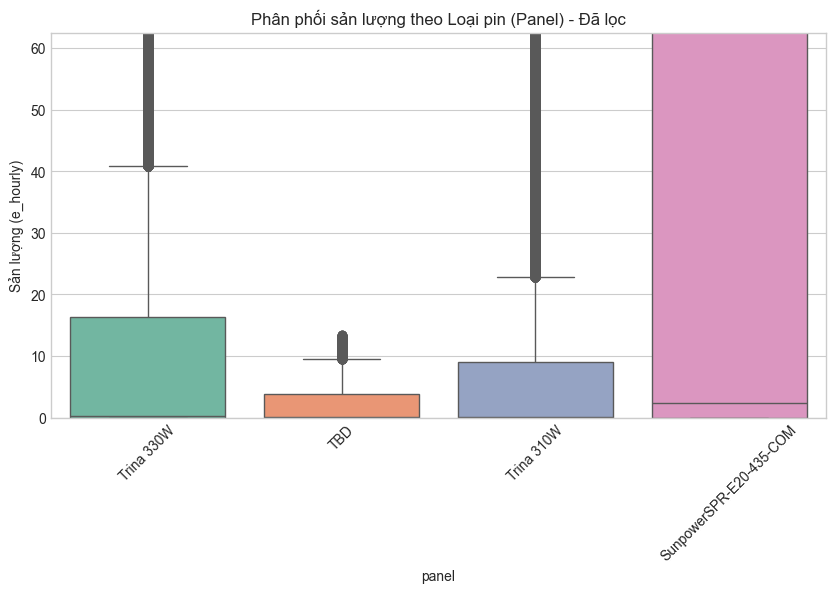

In [8]:
# Thống kê theo loại pin năng lượng (panel)
panel_stats = df_filtered.groupby('panel')['e_hourly'].agg(['count', 'mean', 'sum', 'std']).round(2).sort_values('mean', ascending=False)
display(panel_stats)

plt.figure(figsize=(10,5))
sns.boxplot(x='panel', y='e_hourly', data=df_filtered, palette='Set2')
plt.title('Phân phối sản lượng theo Loại pin (Panel) - Đã lọc')
plt.xticks(rotation=45)
plt.ylabel('Sản lượng (e_hourly)')
plt.ylim(0, df_filtered['e_hourly'].quantile(0.95))
plt.show()


## 8. Khám phá thêm: Ma trận tương quan

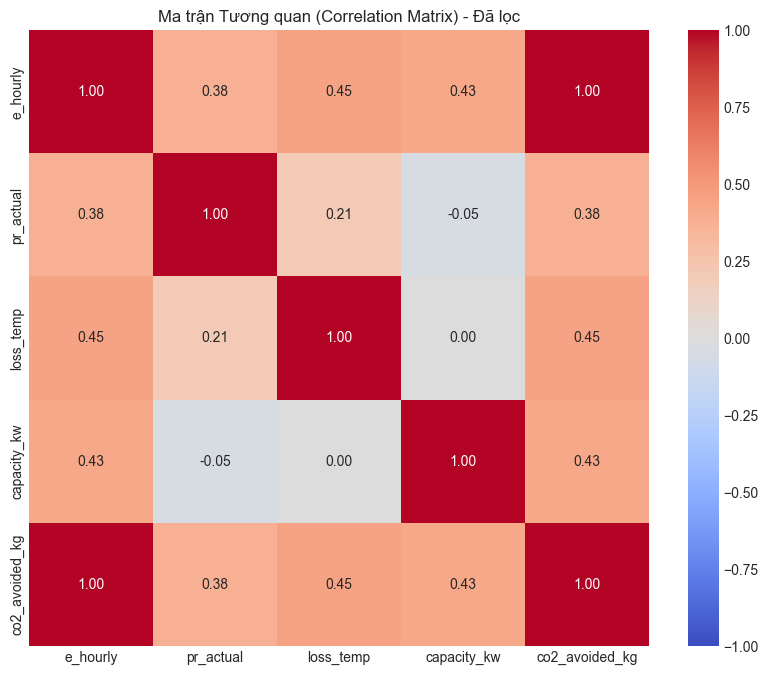

In [9]:
# Ma trận tương quan giữa các biến số
plt.figure(figsize=(10,8))
corr_cols = ['e_hourly', 'pr_actual', 'loss_temp', 'capacity_kw', 'co2_avoided_kg']
corr_matrix = df_filtered[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận Tương quan (Correlation Matrix) - Đã lọc')
plt.show()
